# Final Project for Computational Electromagnetics


# Assignment 5


## A.5.1. Problem description

We seek the capacitance per unit length of  a circular conducting wire placed over the middle of a conducting strip. The wire radius is $a$, and the center of the wire is located at a height $H$ over the strip. The strip has width $w$ and thickness $b$. The geometry is assumed to be two-dimensional and the structure is located in free space. For the computation of the capacitance per unit, it is therefore appropiate to use the method of moments.


For a capacitor where two plates have different shape, the two plates must have opposite total charges. However, they will not in general have opposite potentials. Since Poisson’s equation is linear, the charges and potentials must satisfy the linear relation

$$
q_1 = C_{11}V_1 + C_{12}V_2
$$

$$
q_2 = C_{21}V_1 + C_{22}V_2
$$

where $q_i$ are the charges on the plates and $V_i$ their potentials. The matrix elements $C_{ij}$ of the capacitance matrix are referred to as capacitance coefficients. Note that the capacitance coefficients in themselves are not physically very relevant and they depend on how the normalizing distance is chosen in the expression for the potential from a line charge. The coefficients can be computed by considering two cases where $V_1$ and $V_2$ take linearly independent values, e.g.,

1. $V_1 = 1$ and $V_2 = 0$ yield the values for $C_{11}$ and $C_{21}$.
2. $V_1 = 0$ and $V_2 = 1$ yield the values for $C_{12}$ and $C_{22}$.

To define the capacitance, we require that the net charge is zero. This implies that $q_1 = -q_2 = q$. Then the capacitance is defined as

$$
C = \frac{q}{V_1-V_2}
$$

# Assignments

**Q1:** First express the net capacitance $C$ **analytically** in terms of the capacitance coefficients $C_{11}$, $C_{12}$, $C_{21}$ and $C_{22}$.

**A1:** *Place your answer in this markdown cell.*

## Implementation

The following function can be reused to obtain the charge $q$ and charge density $\sigma$ per element. The function MoM2D was provided in the class and is based on the MATLAB function 2DMoM.m described in Sect. 7.2.2 of our textbook.

In [ ]:
const ε = 8.8541878128
function MoM2D(xs, ys, xe, ye, ϕ)
       
    xobs = 0.5.*(xs + xe)    # Observation points
    yobs = 0.5.*(ys + ye)
    h = sqrt.((xe-xs).^2  + (ye - ys).^2)  # Length of elements
    A = zeros(Float64, length(xs),length(xs))#Matriz para integral
    
    #Loop over elements
    for k in eachindex(xs)
        s = ( (xobs .- xs[k])*(xe[k] .- xs[k])
            + (yobs .- ys[k])*(ye[k] .- ys[k]))./h[k]^2;
        
        d = real(sqrt.(convert.(Complex{Float64}, (xobs .- xs[k]).^2 + (yobs .- ys[k]).^2 - s.^2 .* h[k]^2 .+ 1e-24)))
        # 1e-24 is a simple hack to avoid dealing with ξe/d blowing up to infinity for d=0
        # note that d.*atan.(ξe./d) = 0 for d = 0 (analytically)
        # same is true for x*ln (x^2 + d^2)

        ξs = -s.*h[k]
        ξe = (1 .- s).*h[k]
        
        temp = 0.5*ξe.*log.(ξe.^2 + d.^2) - ξe + d.*atan.(ξe./d) - 
            (0.5*ξs.*log.(ξs.^2 + d.^2) - ξs + d.*atan.(ξs./d))
        A[:, k] = -temp[:]/(2*π*ε)  
    end
    σ = (A\ϕ)      # Charge density
    q = h.*σ       # Charge per element
    return q, σ
end

The following struct can be used to save all the mesh information.

In [1]:
using StaticArrays
using Plots

struct Mesh{I <: Integer, F <: Real}
    vertices::Vector{SVector{2, F}}
    segments::Vector{SVector{2, I}}
end

function numvertices(Ω)
    return length(Ω.vertices)
end

function getvertices(Ω)
    return Ω.vertices
end

function getsegments(Ω)
   return Ω.segments
end

function numsegments(Ω)
    return length(Ω.segments)
end

numsegments (generic function with 1 method)

**Q2:** Write a function that meshes a circle centered at the origin with segment length $h$ and radius passed via the keyword argument `radius`.

**A2:** *Place your implementation in the code cell below.*

In [21]:
function meshcircle(h; radius=1.0)
    
    n = round(Int, 2π*radius/h)  # calculate number of vertices needed
    angles = range(start=0, stop=2π-h, length=n) |> collect# generate angles for each vertex
    x = radius .* cos.(angles)  # calculate x-coordinates of vertices
    y = radius .* sin.(angles)  # calculate y-coordinates of vertices

    SV = SVector{2, Real}
    ST = SVector{2, Int}
    
    vertices = [SV(x[i], y[i]) for i in 1:n]  # create vertices using StaticArrays
    segments = [ST(i, i%n+1) for i in 1:n]  # create segments that connect vertices 
    
    return Mesh(vertices, segments)
end



meshcircle (generic function with 1 method)

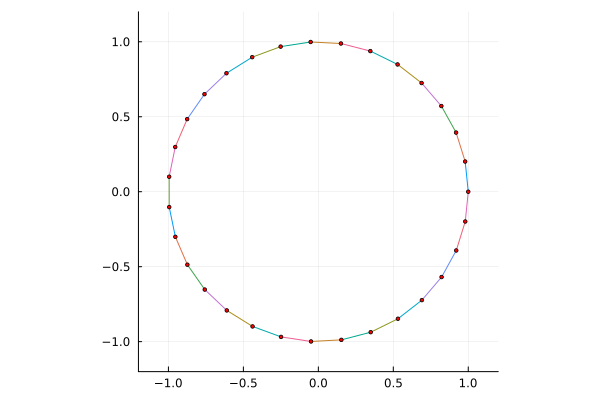

In [26]:
using Plots
mesh= meshcircle(0.2, radius=1.0)
function plotsegments(Ω::Mesh{N, F}) where {N<:Integer, F<:Real}
    v = getvertices(Ω)
    s = getsegments(Ω)
    p = plot(aspect_ratio=:equal, xlims=(-1.2, 1.2), ylims=(-1.2, 1.2), legend=false)
    for i in 1:length(s)
        start_vertex = v[s[i][1]]
        end_vertex = v[s[i][2]]
        plot!(p, [start_vertex[1], end_vertex[1]], [start_vertex[2], end_vertex[2]])
    end
    return p
end
vertices = getvertices(mesh)
plotsegments(mesh)
scatter!([v[1] for v in vertices], [v[2] for v in vertices], mc=:red, ms=2)


**Q3:** Write a function that meshes a rectangle of length $l$ and of width $w$ with segment length $h$.

**A3:** *Place your implementation in the code cell below.*

In [20]:
function meshrectangle(l::Real, w::Real, h::Real)
    @assert l > h
    @assert w > h
    
    n_l = round(Int64, l/h)  #segments alongh width of rectangle
    n_w = round(Int64, w/h)  #segments along thickness of rectangle
    
    SV = SVector{2, Real}
    vs = [SV([i*h, 0.0]) for i in 0:n_l]             # bottom edge
    append!(vs, [SV([l, i*h]) for i in 1:n_w])        # right edge
    append!(vs, [SV([i*h, w]) for i in n_l-1:-1:0])   # top edge
    append!(vs, [SV([0.0, i*h]) for i in n_w-1:-1:1]) # left edge
    
    n = length(vs)
    SS = SVector{2, Int}
    s = [SS([i, mod1(i+1,n)]) for i in 1:n]
    return Mesh(vs, s)
end


meshrectangle (generic function with 3 methods)

**Q4:** Write a function that translates a mesh `Γ` by `δv`.

**A4:** *Place your implementation in the code cell below.*

In [18]:
function translate(Γ::Mesh, δv)
    new_vertices = [v + δv for v in Γ.vertices]
    new_segments = [[j + size(Γ.vertices, 1)*(i-1) for j in seg] for seg in Γ.segments]
    return Mesh(new_vertices, new_segments)
end

translate (generic function with 1 method)

**Q5:** Overload the base `+` operator such that you can generate a new mesh from two existing meshes `Γ1`and `Γ2` by writing `Γ = Γ1 + Γ2`.

**A5:** *Place your implementation in the code cell below.*

In [19]:
function Base.:+(Γ1::Mesh, Γ2::Mesh)
    # shift vertices of Γ2 by the last vertex of Γ1
    vs2 = [v .+ Γ1.vs[end] for v in Γ2.vs]
    
    # concatenate vertices and segments
    vs = vcat(Γ1.vs, vs2)
    s = vcat(Γ1.s, Γ2.s .+ length(Γ1.vs))
    
    return Mesh(vs, s)
end


**Q6:** Write a function that meshes a pair of circular wires with segment length $h$ and distance $d$ between the centers of the wires.

**A6:** *Place your implementation in the code cell below.*

In [ ]:
function get_wirepair(a1, a2, d, h)
    # Your implementation here
end

**Q7:** Write a function that meshes a circular wire above a rectangular plate (i.e., the original problem) with segment length $h$.

**A7:** *Place your implementation in the code cell below.*

In [ ]:
function get_geometry(a, w, b, d, h)
    # Your implementation here
end

**Q8:** Write a function that plots a mesh. Take care the segments are represented via lines.

**A8:** *Place your implementation in the code cell below.*

In [ ]:
function Plots.plot(Γ::Mesh)
    # Your implementation here
end

**Q9:** Plot the geometry in question with with $a=1$ and $b=0.5$, $d=2$, $w=20$, and $h=0.01$.

**A9:** *Place your implementation in the code cell below.*

In [ ]:
# Your implementation here

The MoM2D routine expects vectors of the start and end points.

**Q10:** Write a function that given a `Γ::Mesh` variable returns `xs`, `xe`, `ys`, `ye`.

**A10:** *Place your implementation in the code cell below.*

In [ ]:
# Needed for the MoM routine from class
function get_xy(Γ)
    # Your implementation here
end

**Q11:** Write a function that computes the capacitance matrix for a pair of wires.

**A11:** *Place your implementation in the code cell below.*

In [ ]:
function get_capacitancewpmatrix(a1, a2, d, h)

    # Your implementation here

    C = [C11  C12; C21 C22]
    return C
    
end

**Q12:** Write a function that computes the capacitance for a pair of circular wires.

**A12:** *Place your implementation in the code cell below.*

In [ ]:
"""
    get_capacitance(a, w, b, d, h)

Returns the capacitance of a pair of circular wires.

Arguments:
    a1 = wire radius (top wire)
    a2 = wire radius (bottom wire)
    d = distance of centers of wires
    h = mesh size

Returns:
    C = capacitance
"""
function get_capacitancewp(a1, a2, d, h)

    # Your implementation here

end

**Q13:** Write a function that computes the capacitance matrix for the wire above rectangular plate case.

**A13:** *Place your implementation in the code cell below.*

In [ ]:
function get_capacitancematrix(a, w, b, d, h)

    # Your implementation here

    C = [C11  C12; C21 C22]
    return C
    
end

**Q14:** Write a function that computes the capacitance for the circular wire above rectangular plate case.

**A14:** *Place your implementation in the code cell below.*

In [ ]:
"""
    get_capacitance(a, w, b, d, h)

Returns the capacitance of a circular conducting wire placed over the middle of a conducting strip.

Arguments:
    a = wire radius
    w = width of the strip
    b = thickness of the strip
    d = height of center of the wire over the strip
    h = mesh size

Returns:
    C = capacitance
"""
function get_capacitance(a, w, b, d, h)

    # Your implementation here

end

The analytical formula for the capacitance of pair of circular wires with distance $d$ and radius $a$ is
\begin{equation*}
C = \frac{\pi \varepsilon}{\log\left(\frac{d}{2a} + \sqrt{\frac{d^2}{4 a^2}-1} \right)}\, ,
\end{equation*}
which is implemented by the following Julia function:

In [ ]:
# Analytical solution of wirepair
Cwirepair(d, a) = π*ε/log(d/(2*a) + sqrt(d^2/(4*a^2) - 1) )

# Extra Test with Analytic Solution for Pair of Circular Wires
**Q15:** Implement a test that shows convergences against the analytic solution. Ensure that you include a plot with the relative error in decibels.

**A15:** *Place your implementation in the code cell below*.

In [ ]:
# Your implementation here

**Q16:** Estimate the order of convergence.

**A16:** *Place your answer in this markdown cell and the corresponding code below.*

In [ ]:
# Your implementation here

# Numerical Test #1
Test the program by running the case $a =$  1 mm, $b=$ 0.5 mm, $d =$  2 mm, and $w =$ 20 mm. Determine the order of convergence and make an extrapolation to zero grid size within 1% accuracy.

**Q17:** Propose a technique to ensure 1% accuracy

**A17:** *Place your answer in this markdown cell and the corresponding code below.* 

In [ ]:
# Your implementation here

**Q18:** Determine order of convergence.

**A18:** *Place your answer in this markdown cell and the corresponding code below.* 

In [ ]:
# Your implementation here

**Q19:** Extrapolate to $h \rightarrow 0$.

**A19:** *Place your answer in this markdown cell and the corresponding code below.* 

In [ ]:
# Your implementation here

## Numerical Test #2

Verify that your result for $C$ is reasonably close to the analytical result for an infinite plate, i.e., $w = \infty$.

The analytic formula can be found in Wikipedia (“Wire parallel to wall”)
\begin{equation}
    C_\text{ana}(d, a) = \frac{2 π ε}{\ln\left(\displaystyle\frac{d+\sqrt{d^2-a^2)}}{a}\right)}
\end{equation}
provided as code:

In [ ]:
C_ana(d, a) = 2*π*ε/log((d+sqrt(d^2-a^2))/a) 

**Q20:** Demonstrate convergence

**A20:** *Place your answer in this markdown cell and the corresponding code below.*

In [ ]:
# Your implementation here

## Numerical Test #3

Keeping all the other parameters the same, set $w =$  0.5 mm. Check the order of convergence and extrapolate to zero grid size, with at most 1% error.

**Q21**: Repeat tasks from **Q17**-**Q19**.

**A21**: *Place your answer in this markdown cell and the corresponding code below.* 

In [ ]:
# Your implementation here

# Numerical Test #4

Now you have some idea of what resolution is required. Based on this experience, compute and plot the capacitance as a function of width for the interval 0.2 mm < w < 5 mm.

**Q22:** What $h$ should be choosen?

**A22:** *Place your answer in this markdown cell.* 

**Q23:** Compute capacitances and plot.

**A23:** *Place your answer in this markdown cell and the corresponding code below.*

In [ ]:
# Your implementation here